In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount drive and load data
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/MS JUST/TA/CSE - 3202 - Artificial Intelligence and Machine Learning Lab/Algos/4_SVM/heart.csv'
df = pd.read_csv(file_path)

# Visual Data: Display the dataset and statistical summary as rich tables
print("First 5 rows of the dataset:")
display(df.head())

print("\nBasic Statistical Summary:")
display(df.describe())

Mounted at /content/drive
First 5 rows of the dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Basic Statistical Summary:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# Target Variable distribution

/tmp/ipykernel_7506/2475686117.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='HeartDisease', palette='coolwarm')


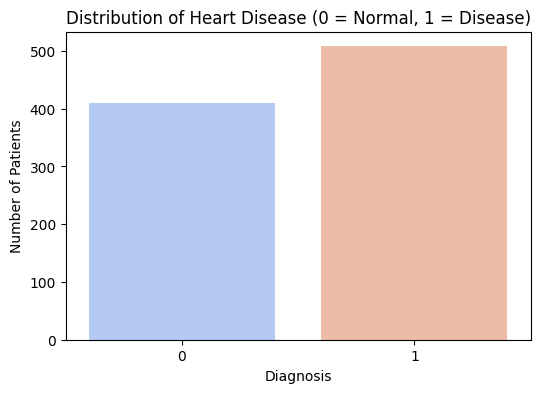

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Data: Bar chart of Heart Disease distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HeartDisease', palette='coolwarm')
plt.title("Distribution of Heart Disease (0 = Normal, 1 = Disease)")
plt.ylabel("Number of Patients")
plt.xlabel("Diagnosis")
plt.show()

# Feature Exploration

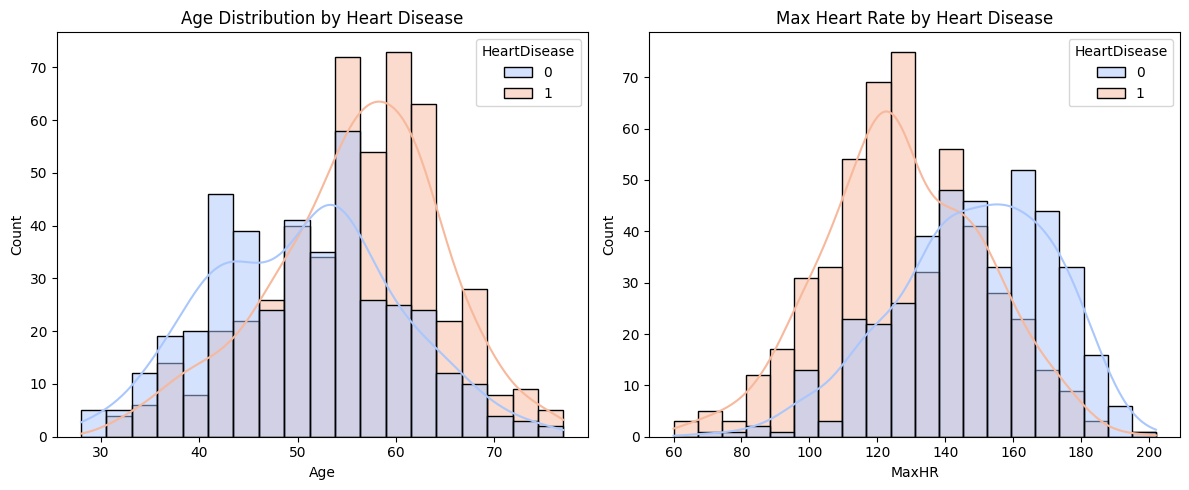

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Data: How Age and Max Heart Rate relate to Heart Disease
plt.figure(figsize=(12, 5))

# Plot 1: Age
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='HeartDisease', kde=True, palette='coolwarm')
plt.title("Age Distribution by Heart Disease")

# Plot 2: Maximum Heart Rate
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='MaxHR', hue='HeartDisease', kde=True, palette='coolwarm')
plt.title("Max Heart Rate by Heart Disease")

plt.tight_layout()
plt.show()

# Preprocess Co-Rel

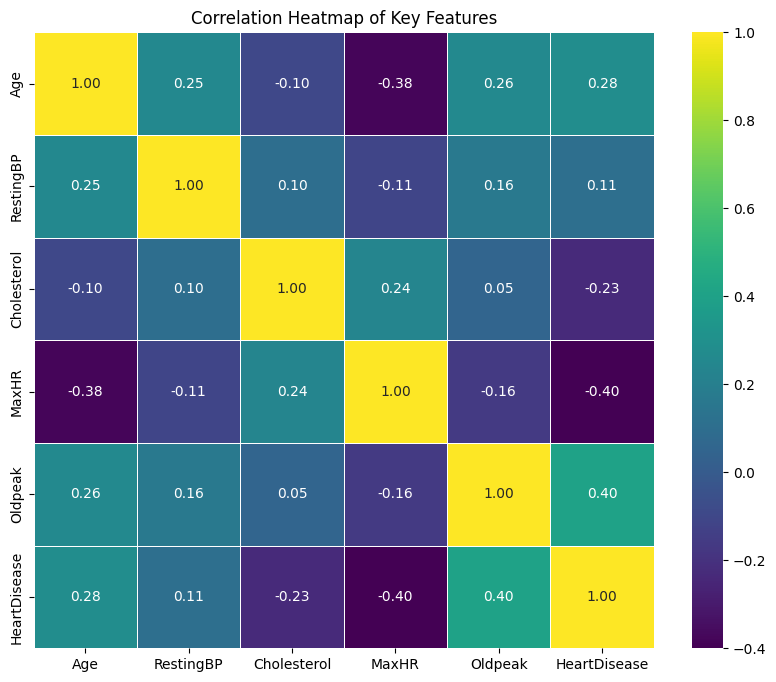

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert text categorical columns to numbers (1s and 0s)
df_encoded = pd.get_dummies(df, drop_first=True)

# Visual Data: Correlation Heatmap of Key Numeric Features
plt.figure(figsize=(10, 8))

# Selecting a subset of important features so the heatmap is easy to read
cols_to_plot = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']
correlation_data = df_encoded[cols_to_plot].corr()

sns.heatmap(correlation_data, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Key Features")
plt.show()

# Acc

Model Accuracy: 85.33%



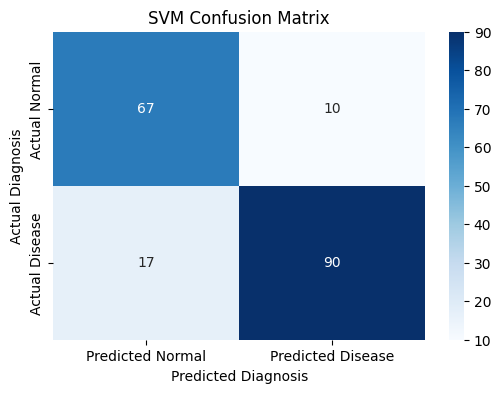

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Separate Features (X) and Target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split into Training (80%) and Testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Crucial for SVM performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the SVM Model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = svm_model.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Visual Data: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Disease'],
            yticklabels=['Actual Normal', 'Actual Disease'])
plt.title('SVM Confusion Matrix')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

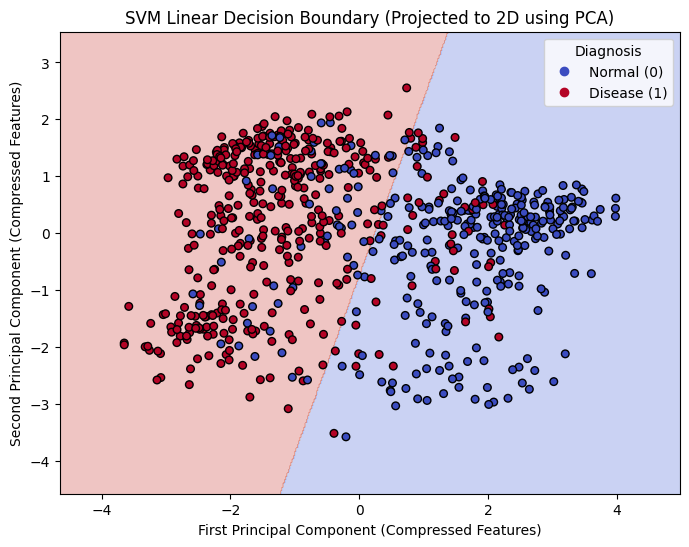

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1. Reduce the high-dimensional scaled data to 2 dimensions using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Train a new SVM on just these 2 dimensions so we can plot it
svm_2d = SVC(kernel='linear', random_state=42)
svm_2d.fit(X_train_pca, y_train)

# 3. Create a grid of points to draw the decision boundary background
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 4. Predict over the grid to find where the line gets drawn
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the decision boundary and the data points
plt.figure(figsize=(8, 6))
# This draws the background color split (the boundary line)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# This plots the actual data points
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='coolwarm', edgecolors='k', s=30)

plt.title('SVM Linear Decision Boundary (Projected to 2D using PCA)')
plt.xlabel('First Principal Component (Compressed Features)')
plt.ylabel('Second Principal Component (Compressed Features)')

# Add a legend for the target variable
plt.legend(handles=scatter.legend_elements()[0], labels=['Normal (0)', 'Disease (1)'], title="Diagnosis")
plt.show()